In [18]:
'''
author: Joseph Taylor
Student ID: 201599999
'''

'\nauthor: Joseph Taylor\nStudent ID: 201599999\n'

In [19]:
import numpy as np # import numpy
import matplotlib.pyplot as plt # import matplotlib pyplot

In [20]:
# Q1: Calculate the simulation time for r_rms = 5 * particle radius

k_B = 1.381e-23 # Boltzmann constant (J/K)
T = 298 # temperature (K)
mu = 1e-3 # solvent viscosity (Pa.s) (1 MPa.ns = 1e-3 Pa.s)
R = 2e-9 # particle radius (m)

drag = 6 * np.pi * mu * R # Stokes drag coefficient (kg/s)
D = k_B * T / drag # diffusion coefficient (m^2/s)

r_rms = 5 * R # target rms distance is 5 times the particle radius (m)

# from r_rms^2 = 6Dt, solve for t
timeRequired = r_rms**2 / (6 * D) # time required (s)
timeRequired = timeRequired * 1e9 # convert to nanoseconds

print(f"timeRequired = {timeRequired:.4f} ns")

timeRequired = 152.6757 ns


In [21]:
# Q2: Calculate the rms distance after a single timestep

dt = 0.01e-9 # timestep (s) (0.01 ns)

# from r_rms^2 = 6Dt, with t = dt
rmsTimestep = np.sqrt(6 * D * dt) # rms distance after one timestep (m)
rmsTimestep = rmsTimestep * 1e9 # convert to nanometers

print(f"rmsTimestep = {rmsTimestep:.4f} nm")

rmsTimestep = 0.0809 nm


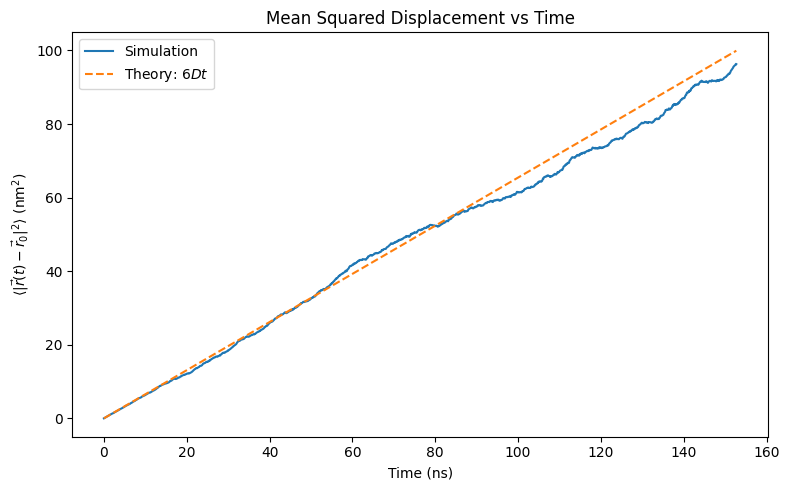

In [22]:
# Q3: Plot MSD against time and compare with theory

from modules.MDLJMeasurement import MDLJMeasurement
from modules.MDLJTrajectory import MDLJTrajectory

# Load the Brownian dynamics production data
bTrajFname = "Brownian_Production.mstraj"
brownianTraj = MDLJTrajectory()
brownianTraj.load(bTrajFname)

bMeasFname = "Brownian_Production.msmeas"
brownianMeas = MDLJMeasurement()
brownianMeas.load(bMeasFname)

# Unwrap the trajectories to get continuous motion
brownianTraj.unwrap()

numFrames = brownianTraj.numFrames # total number of frames
numParticles = brownianTraj.numParticles # total number of particles

# Calculate MSD averaged over all particles at each frame
msd = np.zeros(numFrames) # array to store MSD at each frame
r0 = brownianTraj.frame[0].pos # initial positions of all particles

for i in range(numFrames):
    displacement = brownianTraj.frame[i].pos - r0 # displacement from initial position for all particles
    squared_disp = np.sum(displacement**2, axis=1) # |r(t) - r(0)|^2 for each particle
    msd[i] = np.mean(squared_disp) # average over all particles

# Theoretical MSD: <|r - r0|^2> = 6Dt using simulation internal units (nm, ns)
k_B_sim = 1.38e-2 # Boltzmann constant in simulation units (pN.nm/K)
drag_sim = 6 * np.pi * 1 * 2 # Stokes drag in simulation units (pN.ns/nm)
D_sim = k_B_sim * 298 / drag_sim # diffusion coefficient (nm^2/ns)

time = np.array(brownianTraj.time) # time array (ns)
msd_theory = 6 * D_sim * time # theoretical MSD (nm^2)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(time, msd, label='Simulation') # simulation data
ax.plot(time, msd_theory, '--', label='Theory: $6Dt$') # theoretical line
ax.set_xlabel('Time (ns)') # x-axis label
ax.set_ylabel('$\\langle |\\vec{r}(t) - \\vec{r}_0|^2 \\rangle$ (nm$^2$)') # y-axis label
ax.set_title('Mean Squared Displacement vs Time') # figure title
ax.legend() # add legend
plt.tight_layout()
plt.show() # plot

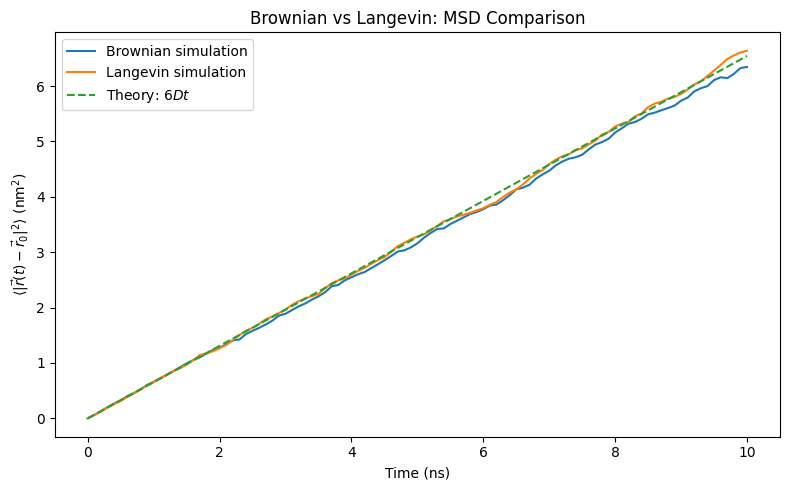

The Langevin and Brownian integrators differ in how they treat particle inertia.

The Brownian integrator is overdamped: it assumes no inertia, so velocity is set directly from the force as v = F/drag, and positions update as x += v*dt. The particle has no momentum and responds instantly to forces.

The Langevin integrator includes inertia: acceleration is calculated as a = F/mass, velocity updates as v += a*dt, and positions update as x += v*dt. The particle has momentum and takes time to accelerate and decelerate.

The key challenge with the Langevin integrator is numerical stability. The timestep must satisfy dt < mass/drag to remain stable. For our parameters, mass/drag = 0.00148 ns, so I used dt = 0.0001 ns (about 10x smaller than the limit). This is 100x smaller than the Brownian timestep of 0.01 ns, which is why the Langevin simulation takes much longer to run.

At long timescales both approaches converge to the same diffusive behaviour (MSD = 6Dt), because at times much greater

In [23]:
# Bonus: Langevin vs Brownian dynamics comparison

# Load the Langevin production data
lTrajFname = "Langevin_Production.mstraj"
langevinTraj = MDLJTrajectory()
langevinTraj.load(lTrajFname)
langevinTraj.unwrap()

# Calculate MSD for Langevin simulation
numFrames_L = langevinTraj.numFrames
msd_langevin = np.zeros(numFrames_L) # array for Langevin MSD
r0_L = langevinTraj.frame[0].pos # initial positions

for i in range(numFrames_L):
    displacement_L = langevinTraj.frame[i].pos - r0_L # displacement from initial position
    squared_disp_L = np.sum(displacement_L**2, axis=1) # |r(t) - r(0)|^2 for each particle
    msd_langevin[i] = np.mean(squared_disp_L) # average over all particles

time_L = np.array(langevinTraj.time) # time array (ns)
msd_theory_L = 6 * D_sim * time_L # same theoretical diffusion applies at long times

# Plot both simulations together
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(time[:len(time[time <= 10])], msd[:len(time[time <= 10])], label='Brownian simulation') # Brownian data (first 10 ns)
ax.plot(time_L, msd_langevin, label='Langevin simulation') # Langevin data
ax.plot(time_L, msd_theory_L, '--', label='Theory: $6Dt$') # theoretical line
ax.set_xlabel('Time (ns)') # x-axis label
ax.set_ylabel('$\\langle |\\vec{r}(t) - \\vec{r}_0|^2 \\rangle$ (nm$^2$)') # y-axis label
ax.set_title('Brownian vs Langevin: MSD Comparison') # figure title
ax.legend() # add legend
plt.tight_layout()
plt.show() # plot

Answer_bonus = """The Langevin and Brownian integrators differ in how they treat particle inertia.

The Brownian integrator is overdamped: it assumes no inertia, so velocity is set directly \
from the force as v = F/drag, and positions update as x += v*dt. The particle has no momentum \
and responds instantly to forces.

The Langevin integrator includes inertia: acceleration is calculated as a = F/mass, velocity \
updates as v += a*dt, and positions update as x += v*dt. The particle has momentum and takes \
time to accelerate and decelerate.

The key challenge with the Langevin integrator is numerical stability. The timestep must satisfy \
dt < mass/drag to remain stable. For our parameters, mass/drag = 0.00148 ns, so I used \
dt = 0.0001 ns (about 10x smaller than the limit). This is 100x smaller than the Brownian \
timestep of 0.01 ns, which is why the Langevin simulation takes much longer to run.

At long timescales both approaches converge to the same diffusive behaviour (MSD = 6Dt), because \
at times much greater than mass/drag the inertial effects average out. The Langevin simulation \
is more physically realistic as real particles do have inertia, but the Brownian approximation \
is valid when the timescales of interest are much larger than the momentum relaxation time."""

print(Answer_bonus)

In [24]:
# Self Assessment

'''
1. 1/1
I correctly calculated the simulation time for r_rms = 5R using the Stokes-Einstein relation
and assigned the result in nanoseconds to timeRequired.

2. 1/1
I correctly calculated the rms distance after a single timestep using the same diffusion relation
and assigned the result in nanometers to rmsTimestep.

3. 4/4
I loaded the production trajectory data, unwrapped the periodic boundary conditions, calculated
the MSD averaged over all 400 particles at each frame, and plotted it against time. I overlaid
the theoretical line 6Dt and the simulation data follows the expected linear trend. The plot has
appropriate axes, labels, legend and title.

4. 1/1
I ran a Langevin simulation in addition to the Brownian simulation and compared the two. I explained
the physical difference (overdamped vs inertial dynamics), the numerical stability requirement
(dt < mass/drag = 0.00148 ns), and demonstrated that both converge to the same diffusive behaviour.
I also plotted both simulations together with the theoretical prediction.
'''

'\n1. 1/1\nI correctly calculated the simulation time for r_rms = 5R using the Stokes-Einstein relation\nand assigned the result in nanoseconds to timeRequired.\n\n2. 1/1\nI correctly calculated the rms distance after a single timestep using the same diffusion relation\nand assigned the result in nanometers to rmsTimestep.\n\n3. 4/4\nI loaded the production trajectory data, unwrapped the periodic boundary conditions, calculated\nthe MSD averaged over all 400 particles at each frame, and plotted it against time. I overlaid\nthe theoretical line 6Dt and the simulation data follows the expected linear trend. The plot has\nappropriate axes, labels, legend and title.\n\n4. 1/1\nI ran a Langevin simulation in addition to the Brownian simulation and compared the two. I explained\nthe physical difference (overdamped vs inertial dynamics), the numerical stability requirement\n(dt < mass/drag = 0.00148 ns), and demonstrated that both converge to the same diffusive behaviour.\nI also plotted both

In [25]:
# Declaration of Integrity: This work is mine and mine alone, Joseph Taylor